Source Used: https://data.wprdc.org/dataset/condemned-properties/resource/0a963f26-eb4b-4325-bbbc-3ddf6a871410

Using condemned properties was done as a metric to determine how good a neighborhood would be through the ones that have lesser condemned properties so that if you were to live there you would not have the eyesore that they can bring along with any hazards posted from them. This shows a graph of the top 50 neighborhoods with the most condemned then a table with all the ones that only contained 1. Due to the nature of this data however any neighborhood that would not have any condemned properties would not be on the list and therefore would not be known thus potentially causing a slight skew to what final scores would be to determine the best neighborhood. 

With this notebook at first the data is cleaned up to be able to be properly used later. After cleaning the data, it is gone through to find any current data and getting the most recent versions of them to not count one more than once. After this only the fail results are accounted for and anything with passing or none is ignored to keep the data more consistent and easier to understand. After this a running tally for each fail is done for all neighborhoods. Then the top 50 are shown for the worst ones with the final thing being the neighborhooods that only contained 1 condemned property. 

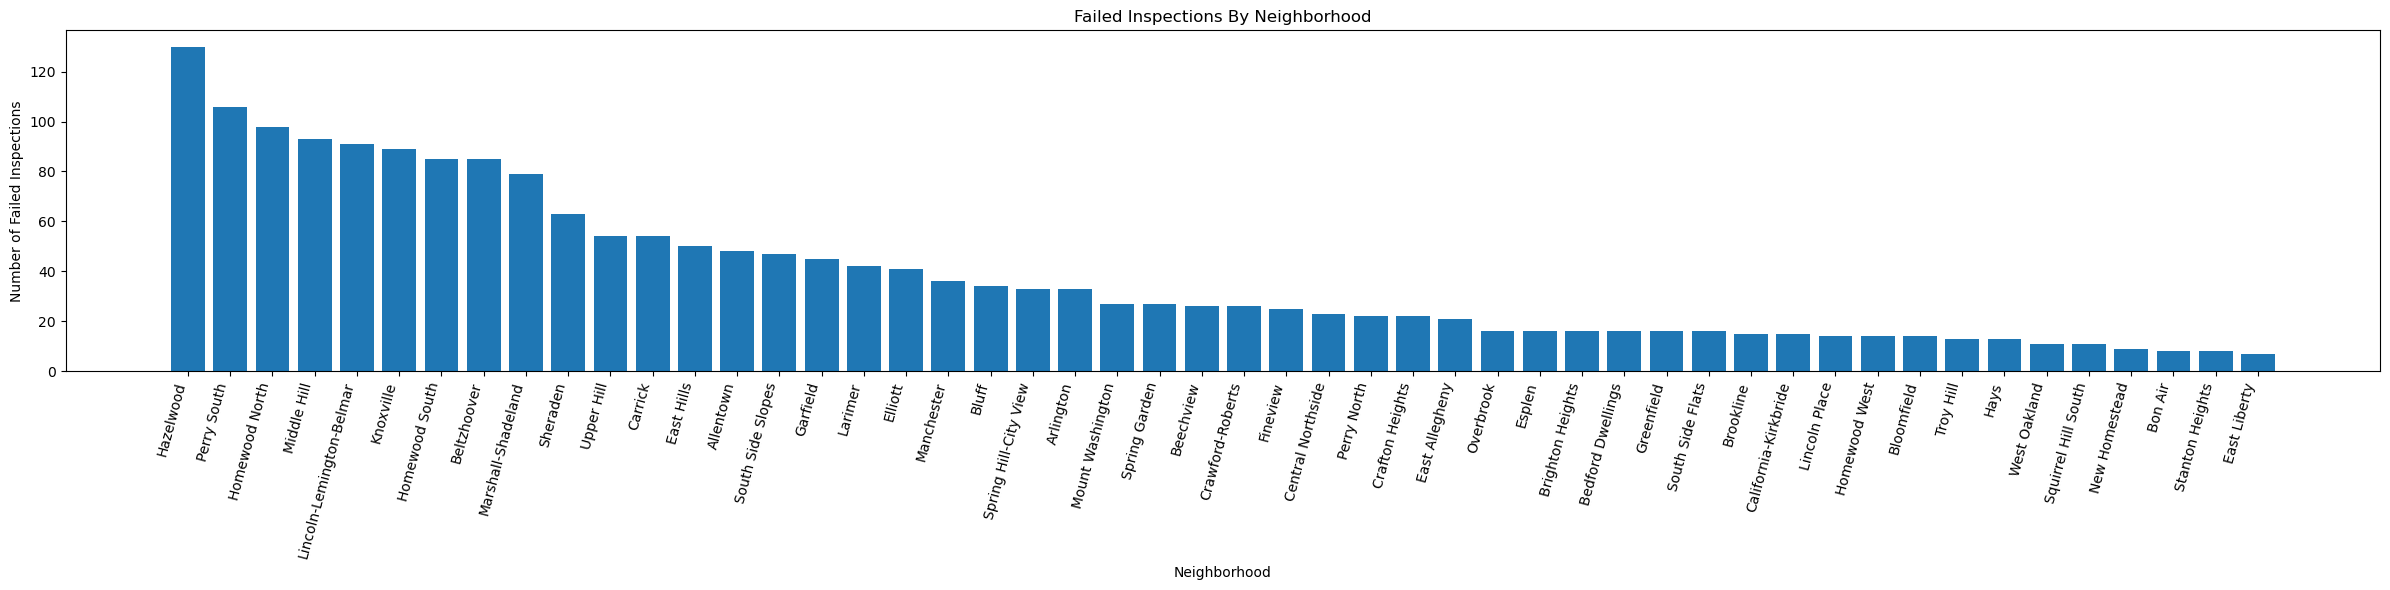

Neighborhoods with 1 condemned properties:
                 neighborhood  fail_count
15  Central Business District           1
0              Allegheny West           1
29                 Friendship           1
19                    Chateau           1
31                 Glen Hazel           1
51              North Oakland           1
64                South Shore           1
74             Swisshelm Park           1
72             Strip District           1
73                Summer Hill           1


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

#Loading the dataset
df = pd.read_csv("Properties.tsv", sep="\t")

#Cleaning column names -- remocing any extra spaces, converting to all lowercase to properly search through, and replacing spaces with _ so that can use properly
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df['create_date'] = pd.to_datetime(df["create_date"], errors='coerce')
df = df.dropna(subset=['neighborhood', 'latest_inspection_result', 'create_date'])

#Trying to get only the latest inspection
if 'street_address' in df.columns:
    df_latest = df.sort_values('create_date').groupby('street_address').tail(1)
else:
    df_latest = df.sort_values('create_date')

#Filtering for fail results
fails = df_latest[df_latest['latest_inspection_result'].str.lower() == 'fail']

#Counting fails for each neighborhood
fail_counts = fails.groupby('neighborhood').size().reset_index(name='fail_count')
fail_counts = fail_counts.sort_values(by='fail_count', ascending=False)

#print("\nFail counts by neighborhood:")
#print(fail_counts.head(50))

#Displaying a graph to show the top 50 neighborhoods that had the highest failures
top50 = fail_counts.head(50)

#Creating a bar chart to display this data
plt.figure(figsize=(24,6))
plt.bar(top50['neighborhood'], top50['fail_count'])
plt.xticks(rotation=75, ha='right')
plt.xlabel("Neighborhood")
plt.ylabel("Number of Failed Inspections")
plt.title("Failed Inspections By Neighborhood")
plt.tight_layout()
plt.show()

#Filter results to only contain those that are <= 1 in terms of fail results
low_fail = fail_counts[fail_counts['fail_count'] <=1]

#plt.figure(figsize=(12,8))
#plt.barh(low_fail['neighborhood'], low_fail['fail_count'])
#plt.gca().invert_yaxis()
#plt.xlabel("Number of Condemned Properties")
#plt.ylabel("Nieghborhood")
#plt.title("Neighborhoods with 0-1 condemned Properties")
#plt.tight_layout()
#plt.show()

#Displaying the neighborhoods that had the least amount of results
best_neighborhoods = low_fail[low_fail['fail_count'] == 1]
print("Neighborhoods with 1 condemned properties:") 
print(best_neighborhoods)

#print("\nAll Neighborhoods")
#print(fail_counts.to_string())